<a href="https://colab.research.google.com/github/fischdakid/is-4487-labs/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/content/hotels.csv')
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders in this dataset are anyone who is involved in the hotel. This is includes: hotel guest, managers, owners, employees, and third party bookers.

2. For hotel guest the goals would be to have an affordable and enojoyable stay at the hotel with good interactions with the employees. For the owners and managers the goals would be to maximize the number of hotel bookings and limit cancellations or issues with guests staying at the hotel. For employees it would be to help guests with any needs and create a connection to gain return customers. For the third party bookers the goal could be to get book as many guests with possible whiile maximizing there earnings.

3. Can historical booking data be used to forecast occupancy by month/week, so the hotel can plan staffing and inventory in advance?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [3]:
# Display data information
df.info()

# Display descriptive statistics
display(df.describe())

# Find the number of Null values for each column
print('\nNumber of Null values per column:')
display(df.isnull().sum())

# Find the number of duplicate rows
print(f'\nNumber of duplicate rows: {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Number of Null values per column:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0



Number of duplicate rows: 31994


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. There are a lot of missing values in this dataset which is a bit of an issue. For example there are 4 missings values for children, 488 missing values for country, 16,000+ missing values for agent, and 112,000+ missing values for company along with there being 31,994 duplicate values in this dataset.

2. Fixing these structural issues could end up being difficult but also important for getting the right data. It could be very important to sumarize those duplicates and decide where or not to remove or replace them. For the missing values it would be useful to look at what the values really mean in this dataset and accessing they are also needed.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

### Univariate Analysis of Key Variables

--- Analysis of lead_time ---


,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


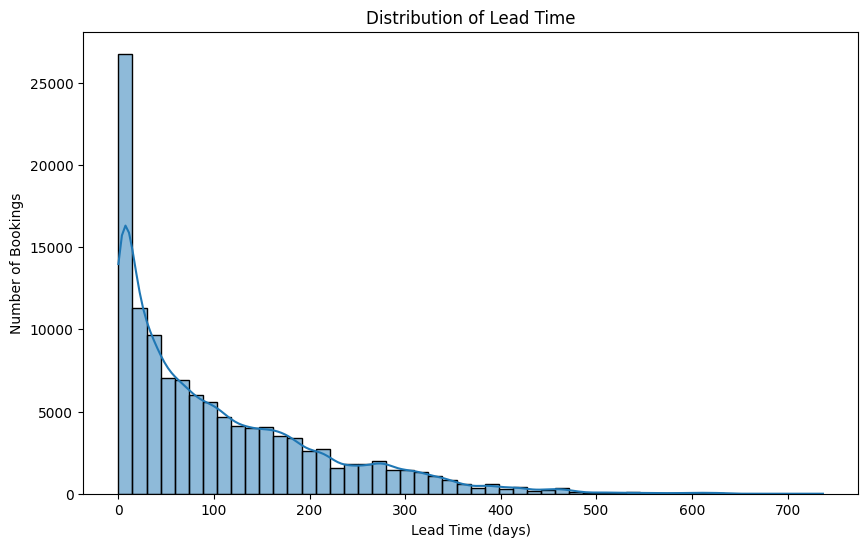

In [4]:
print('--- Analysis of lead_time ---')
display(df['lead_time'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.show()


--- Analysis of adr (Average Daily Rate) ---


,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


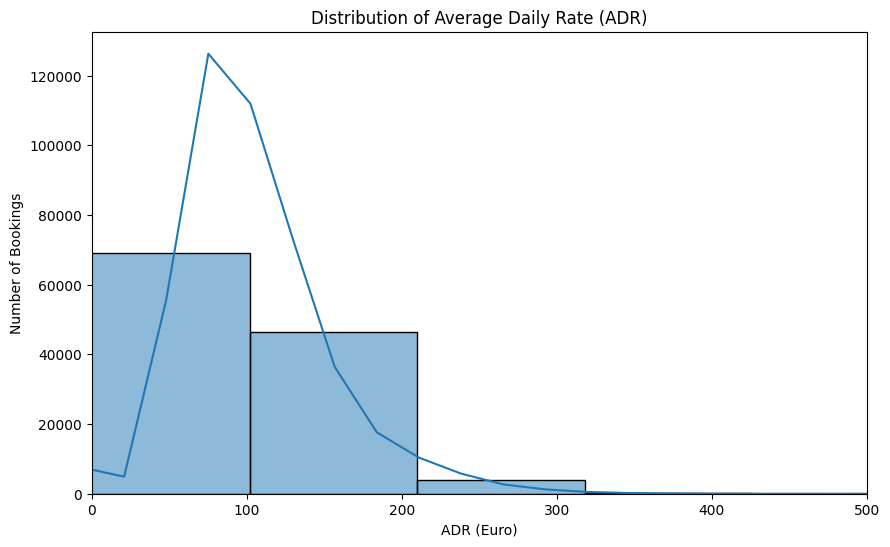

In [5]:
print('\n--- Analysis of adr (Average Daily Rate) ---')
display(df['adr'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['adr'], bins=50, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR (Euro)')
plt.ylabel('Number of Bookings')
plt.xlim(0, 500) # Limiting x-axis for better visualization of main distribution
plt.show()


--- Analysis of is_canceled ---


,Cancellation Rate (%)
is_canceled,
0,62.958372
1,37.041628


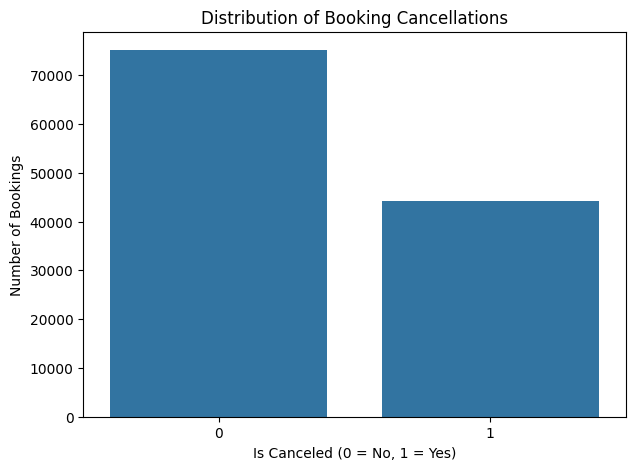

In [6]:
print('\n--- Analysis of is_canceled ---')
display(df['is_canceled'].value_counts(normalize=True).mul(100).rename('Cancellation Rate (%)').to_frame())

plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df)
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  Lead time & number of bookings: In this graph I can see that the data is positivly skewed to the right. This shows that lead time is negatively correlated to number of bookings. There are more people booking with a lower lead time then with a lead time far out in advanbce.  
- **Variable 2 – Summary and insights:**  ADR & Number of Bookings: The second chart is skewed similarly to showing that lower ADR correlates to higher number of bookings. I think this has similar reasoning to the others and makes me think that many people book last second hotels.
- **Variable 3 – Summary and insights:**  Cancellations & Number of bookings: In this bar chart I can see the relationship between cancellations and bookings. What it looks like is that for every booking there is slightly more than half that amount of cancelations. I think people these days tend to cancel a lot more trips or even one night stays related to travel issues which you can see on this chart.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

### Bivariate Analysis of Key Relationships

--- Relationship between Lead Time and Cancellation ---


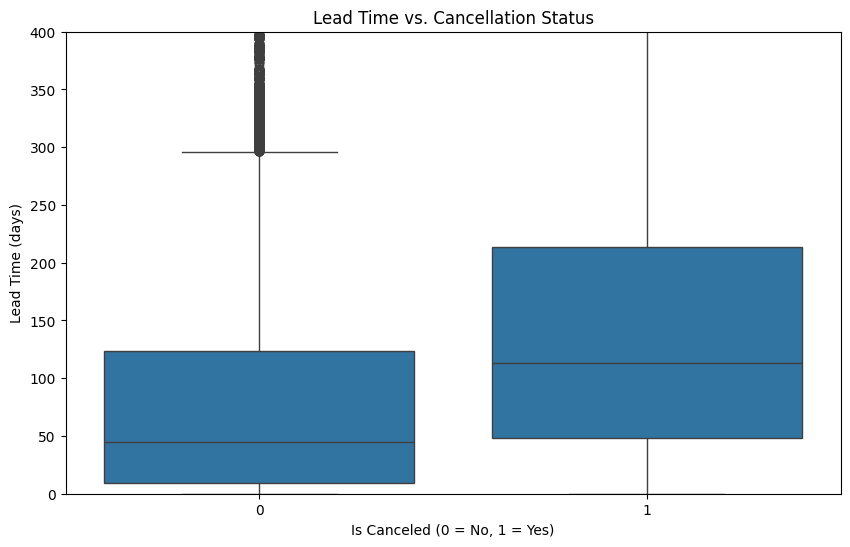


Average Lead Time for Canceled vs. Not Canceled Bookings:


,lead_time
is_canceled,
0,79.984687
1,144.848815


In [9]:
print('--- Relationship between Lead Time and Cancellation ---')
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs. Cancellation Status')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (days)')
plt.ylim(0, 400) # Limit y-axis for better visualization
plt.show()

cancellation_by_lead_time = df.groupby('is_canceled')['lead_time'].mean()
print('\nAverage Lead Time for Canceled vs. Not Canceled Bookings:')
display(cancellation_by_lead_time)


--- Relationship between Hotel Type and Average Daily Rate (ADR) ---


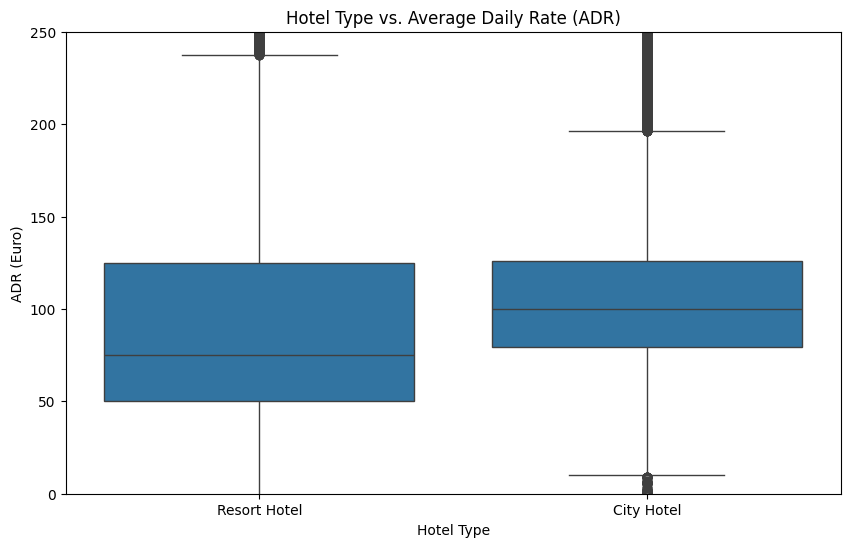


Average ADR by Hotel Type:


,adr
hotel,
City Hotel,105.304465
Resort Hotel,94.952930


In [10]:
print('\n--- Relationship between Hotel Type and Average Daily Rate (ADR) ---')
plt.figure(figsize=(10, 6))
sns.boxplot(x='hotel', y='adr', data=df)
plt.title('Hotel Type vs. Average Daily Rate (ADR)')
plt.xlabel('Hotel Type')
plt.ylabel('ADR (Euro)')
plt.ylim(0, 250) # Limit y-axis for better visualization
plt.show()

adr_by_hotel = df.groupby('hotel')['adr'].mean()
print('\nAverage ADR by Hotel Type:')
display(adr_by_hotel)

### Bivariate Analysis of Key Relationships

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  One of the relationships that I looked at is Lead time vs Cancellation status which tells me that bookings that are eventually canceled tend to have a longer lead time then the bookings that aren't canceled. I think this is probably because those short lead time bookings are usually last minute and most people aren't going to bail out on a last minute hotel that the booked because its probably related to something important.
- **Relationship 2:**  
The next relationship is hotel type vs average daily rate which shows me that there is a big difference in hotel types and ADR. What I can assume is that in city hotels have a higher cost per night compared ot resort hotels because of the amount of people likely traveling to these places. Even if hotels are worse in the city if its a popular destination people are still likely to pay a high price to stay there.  

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1.  **Selected Insight:** Bookings with significantly longer lead times show a higher likelyhood to be canceled compared to those booked closer to the arrival date. I think this is because when someone books a last minute hotel its usual for emergency rather than leasure so they are much less likely to cancel

2.  **Complexity Involved:**
The majority of complexity related to variblity in terms of lead time and cancellations. Both fo these have lots of variablity in the data. Along with that another element of complexity is Volume for the hotel. This could mean increased bookings during busy seasons/holidays which makes things difficult. Lastly, there is another level of complexity with variety because there are definitley other factors than lead time that play a big role in cancellations.

3.  **Type of Analytics that would help, and why:**

Predictive: Building a predictive model could be super helpful for these hotels or people analyzing the data in order to see future trends and be able to predict the exact type of bookings that are likely end up being cancellations. This could help the hotels be more proactive rather then reactive in filling those rooms and making sure they have room for guest that will actually complete there stay.

Prescriptive: Using predictive techniques and diagnostics, prescriptive analytics could help hotel companies with actually recommending actions for them to take. What this could look like could be changing the deposit policies, and integrating flexible booking options for customers with long lead times. Prescriptive analytics could help provide actual insight into how to stop these issues.
    

## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The main pattern that stood out to me during this assignment was the relationship between lead time and cancellations. Going into this I wouldn't have expected that longer lead time for hotel bookings would correlated to higher cancellation rate, but after looking at the data it makes perfect sense. People booking a hotel way out in advance of more time to end up cancelling there trip or running into unseen complications so they are more likely to bail on the trip. Another Pattern that stood out to me in this assignment was the ratio of Cancellations to bookings. I was also suprised by this because I don't really think its that easy to get your money back from a hotel but stil the ratio shows that per 1 booking there is over 1/2 cancellations. If I was running a hotel I would be super concerned by this stat because that means they are loosing out on lots of money.

2. These issues connect directly to the hotel staff, managers, and owners because they are the ones that have to deal with these cancellations and make up for it somehow. These problems also connect to the hotel guests because they are the ones who are either staying at the hotel or cancelling. The hotel staff, managers, and owners need to find a way of dealing with these problems and mitigating the number of cancellations.

3. My recommendation based on this analysis would be to change the policy related to lead time bookings and up front deposits from people. Maybe this looks like lower the deposit for last minute bookings at the hotel and increasing the non-refundable deposit for the guest with a long lead time to incentivize them to go through with there trip or if they do cancel it still makes sure the hotel isn't loosing out on too much money.

4. The way this assignment ties into my customized learning outcomes is because its actually hands on work that makes me look at real data. One thing that I really apprreciate in a class is when the work for the class actually ties to real life problems or is teaching me skills that I can use in the workforce. This assignment does both. I am having to analyze data and interpret it into real conclusions. This is probably similar to what I will be doing at a job in the future and I am thankful that the skills I am leanrning in this class are transferable to the real world.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [11]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] Converting notebook assignment_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 530853 bytes to assignment_05_eda.html
